🇳🇬 **NIGERIA**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore

In [2]:
df = pd.read_csv("/content/nigeria.csv")
df["Country"] = "Nigeria"

In [3]:
df["Date"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")
df["Month"] = df["Date"].dt.month


In [4]:
df.replace(-999, np.nan, inplace=True)

In [5]:
df.drop_duplicates(inplace=True)

### Interpretation
Columns with >5% missing values indicate measurement gaps in climate sensors or satellite limitations.

In [6]:
cols = ["T2M","T2M_MAX","T2M_MIN","PRECTOTCORR","RH2M","WS2M","WS2M_MAX"]
z = df[cols].apply(zscore)

### Outlier Handling Decision
Outliers are retained because they represent extreme weather events, which are critical for climate analysis.

In [7]:
df = df.dropna(thresh=int(len(df.columns)*0.7))
df.fillna(method="ffill", inplace=True)


/tmp/ipykernel_14766/1946195159.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method="ffill", inplace=True)


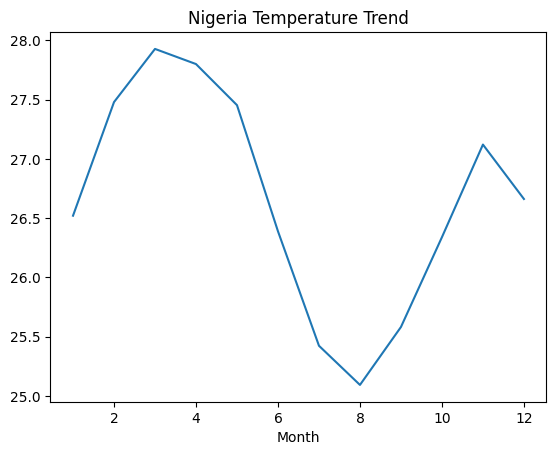

In [8]:
df.groupby("Month")["T2M"].mean().plot()
plt.title("Nigeria Temperature Trend")
plt.show()


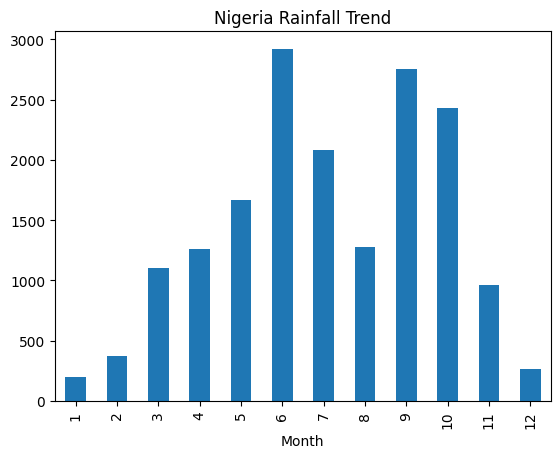

In [9]:
df.groupby("Month")["PRECTOTCORR"].sum().plot(kind="bar")
plt.title("Nigeria Rainfall Trend")
plt.show()

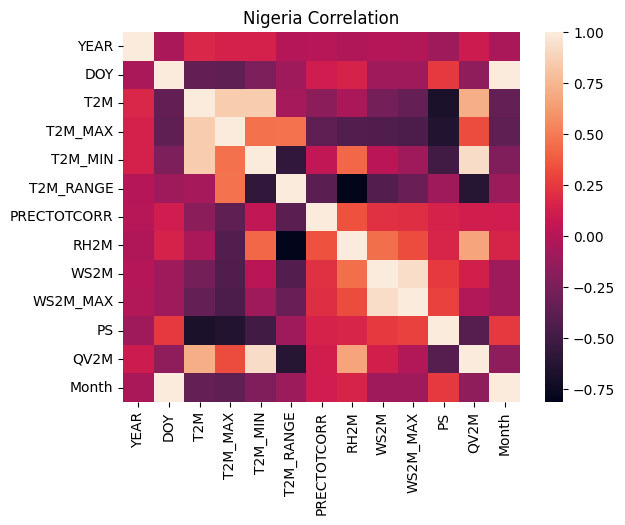

In [10]:
sns.heatmap(df.corr(numeric_only=True))
plt.title("Nigeria Correlation")
plt.show()